In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import h5py, os

from utils.enzo import IA2Data, IA2, get_redshift
from utils.visualize import set_style, DefaultStyle, get_cbar

In [2]:
set_style()

In [3]:
Path = "/media/yange/MyDrive/2024PhDData/EnzoIA2/E14-R"
ia2 = IA2Data(Path)

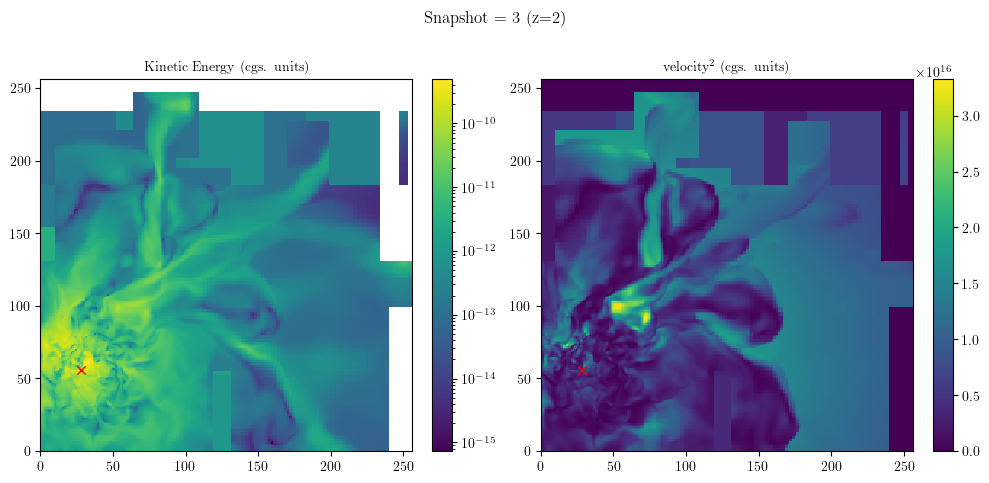

In [40]:
snapshot = 3
c = 5
centre = ia2.get_centre(snapshot=snapshot,c=c)


with h5py.File(os.path.join(Path,'derivedfields.h5')) as f:
    v2 = f[f'{snapshot}/twice-specific-energy'][centre[0]]

rho = ia2.get_val('Density',snapshot=snapshot,slc=centre[0],c=c,)

fig, (ax,ax1) = plt.subplots(1,2,figsize=(10,5),tight_layout=True)
fig.suptitle(f'Snapshot = {snapshot} (z={get_redshift(snapshot)})')

ax.set_aspect('equal')
ax.set_title(f'Kinetic Energy (cgs. units)')
im = ax.pcolormesh((v2*rho/2),
                   norm=colors.LogNorm()
                  )
ax.scatter(centre[2],centre[1],marker='x',color='r')
cbar = get_cbar(im,fig,ax)
# cbar.set_label('Kinetic Energy (cgs. units)')

ax1.set_aspect('equal')
ax1.set_title(r'velocity$^2$ (cgs. units)')
im = ax1.pcolormesh(v2,
                   # norm=colors.LogNorm()
                  )
ax1.scatter(centre[2],centre[1],marker='x',color='r')
cbar = get_cbar(im,fig,ax1)
# cbar.set_label('Kinetic Energy (cgs. units)')

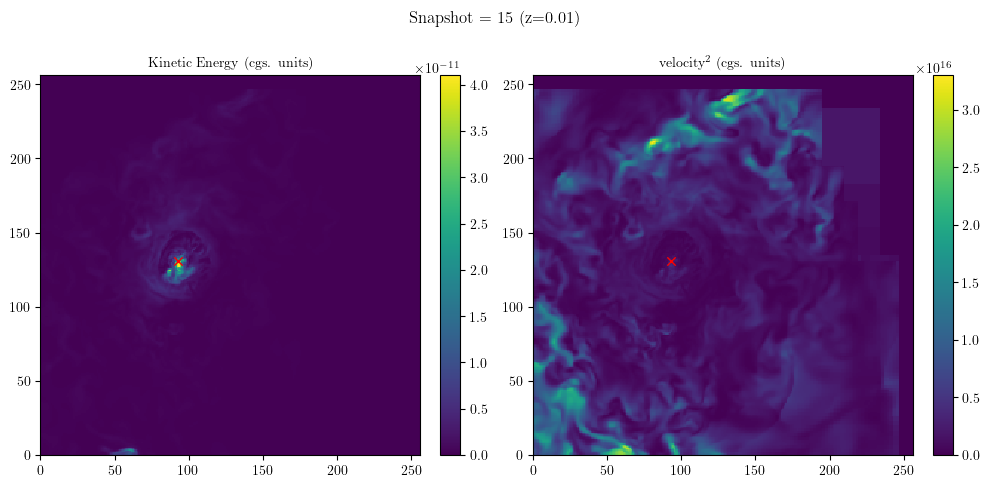

In [50]:
snapshot = 15
c = 5
centre = ia2.get_centre(snapshot=snapshot,c=c)

with h5py.File(os.path.join(Path,'derivedfields.h5')) as f:
    v2 = f[f'{snapshot}/twice-specific-energy'][centre[0]]

rho = ia2.get_val('Density',snapshot=snapshot,slc=centre[0],c=c,)

fig, (ax,ax1) = plt.subplots(1,2,figsize=(10,5),tight_layout=True)
fig.suptitle(f'Snapshot = {snapshot} (z={get_redshift(snapshot)})')

ax.set_aspect('equal')
ax.set_title(f'Kinetic Energy (cgs. units)')
im = ax.pcolormesh((v2*rho/2),
                   # norm=colors.LogNorm()
                  )
ax.scatter(centre[2],centre[1],marker='x',color='r')
cbar = get_cbar(im,fig,ax)
# cbar.set_label('Kinetic Energy (cgs. units)')

ax1.set_aspect('equal')
ax1.set_title(r'velocity$^2$ (cgs. units)')
im = ax1.pcolormesh(v2,
                   # norm=colors.LogNorm()
                  )
ax1.scatter(centre[2],centre[1],marker='x',color='r')
cbar = get_cbar(im,fig,ax1)
# cbar.set_label('Kinetic Energy (cgs. units)')

In [19]:
from utils.gradient import curl_discrete

In [20]:
vx = ia2.get_val('x-velocity',snapshot=15,c=5)
vy = ia2.get_val('y-velocity',snapshot=15,c=5)
vz = ia2.get_val('z-velocity',snapshot=15,c=5)

In [21]:
vor = curl_discrete(vx,vy,vz)
vor_mag = np.sum([vorx**2 for vorx in vor],axis=0)**.5

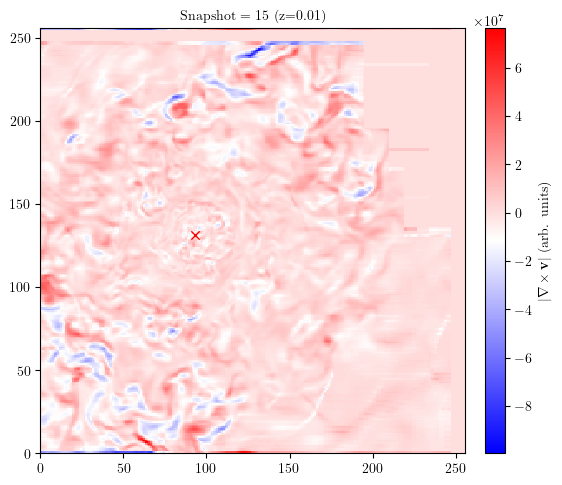

In [49]:
centre = ia2.get_centre(snapshot=snapshot,c=c)

fig, ax = plt.subplots(figsize=(6,6))

ax.set_aspect('equal')
ax.set_title(f'Snapshot = {snapshot} (z={get_redshift(snapshot)})')
im = ax.pcolormesh(vor[2][centre[0]],
                   # norm=colors.LogNorm()
                   cmap='bwr'
                  )
ax.scatter(centre[2],centre[1],marker='x',color='r')
cbar = get_cbar(im,fig,ax)
cbar.set_label(r'$|\nabla\times\mathbf{v}|$ (arb. units)')